In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from surmof_cavity import eps_cav, eps_ag
import matplotlib as mpl

In [2]:
%config InlineBackend.figure_format='retina'

In [3]:
!export JAX_PLATFORMS=cpu

In [4]:
to_THz = 300/2/np.pi
freq_range = (380, 490)
mm = 0.1/2.54

In [5]:
# fnames = [
#     "out/subdivide_smat_1pole.pkl",
#     "out/small_d_smat_1pole.pkl"
# ]
# npoles = 1
# name = "large_sweep_1pole"
# fig_width = 90*mm

# fnames = [
#     "out/subdivide_smat.pkl",
#     "out/small_d_smat_3pole.pkl",
#     #"fine_3pole.pkl"
# ]
# npoles = 3
# name = "large_sweep_3pole"
# fig_width = 190*mm

osc=1
fnames = [
    f"fine_1pole_{osc}osc.pkl",
]
npoles = 1
name = f"{osc}osc_1pole"
fig_width = 90*mm


poles = []
residues = []
thickness = []

for fname in fnames:
    with open(fname, "rb") as file:
        results = pickle.load(file)

    poles += results['poles']
    residues += results['residues']
    thickness += list(results['thickness'])

sorter = np.argsort(thickness)
poles    = [poles[i]    for i in sorter]
residues = [residues[i] for i in sorter]
thickness = np.array(thickness)[sorter]


2024-12-06 14:29:09.584670: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.5.82. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


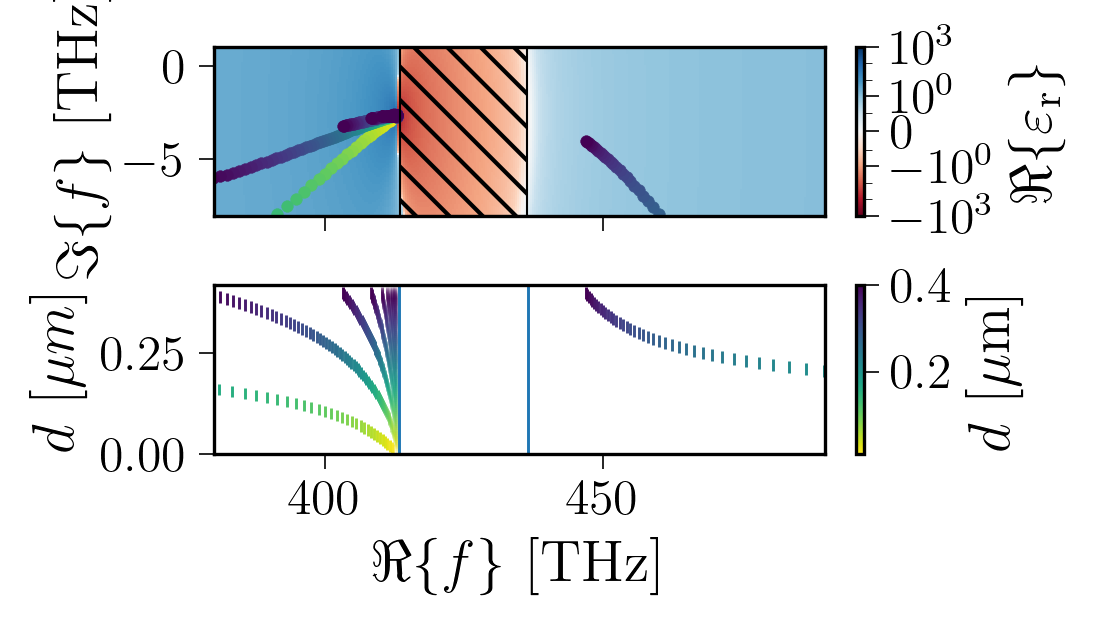

In [6]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(90*mm,50*mm), constrained_layout=True)
plt.sca(axs[0])
w_r = np.linspace(380, 490, 300)
#w_i = np.linspace(-3.7, -2.5, 100)
w_i = np.linspace(-8, 1, 100)
#w_i = np.linspace(-600, 1, 100)
W_r, W_i = np.meshgrid(w_r, w_i)
W = W_r +1j*W_i
eps = eps_cav(W/to_THz, npoles, osc)# eps_ag(W/to_THz) #

eps_r = eps_cav(w_r/to_THz, npoles, osc)# eps_ag(w_r/to_THz) #
lines = 0.5*(w_r[:-1]+w_r[1:])[np.diff(eps_r>0)!=0]

plt.pcolormesh(W_r, W_i, np.real(eps), norm=mpl.colors.SymLogNorm(linthresh=0.1,
                                              vmin=-1000.0, vmax=1000.0, base=10),
                    cmap="RdBu", rasterized=True)
plt.colorbar(label="$\Re\{\\varepsilon_\mathrm{r}\}$", ticks=[-1e3, -1, 0, 1, 1e3])
plt.ylim(plt.ylim())
plt.xlim(plt.xlim())

cmap = mpl.cm.viridis_r
norm = mpl.colors.Normalize(vmin=min(thickness), vmax=max(thickness))
colors = cmap(norm(thickness))
for color, p, r in zip(colors, poles, residues):
    plt.scatter(p.real*to_THz, p.imag*to_THz, color=color)#, s=np.sqrt(np.abs(r))*100)

plt.ylabel("$\Im\{f\}$ [THz]")
plt.savefig("pole_movement.png", dpi=600)

plt.fill_between(w_r, 0, 1, hatch="\\\\\\", where=eps_r.real<0, color="none", edgecolor="k", transform=plt.gca().get_xaxis_transform(), lw=0.5)

plt.sca(axs[1])
plt.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm), ax=plt.gca(), label="$d$ [$\mathrm{\mu m}$]")
for color, t, p, r in zip(colors, thickness, poles, residues):
    plt.scatter(np.real(p)*to_THz, [t]*len(p), color=color, marker="|", 
                alpha=np.clip(10*np.sqrt(np.abs(r)), 0, 1))

for line in lines:
    plt.axvline(line)

plt.ylim((0, None))
plt.xlabel("$\Re\{f\}$ [THz]")
plt.ylabel("$d$ [$\mu m$]")
plt.xlim(min(w_r), max(w_r))

plt.savefig(f"{name}_movement.pdf")

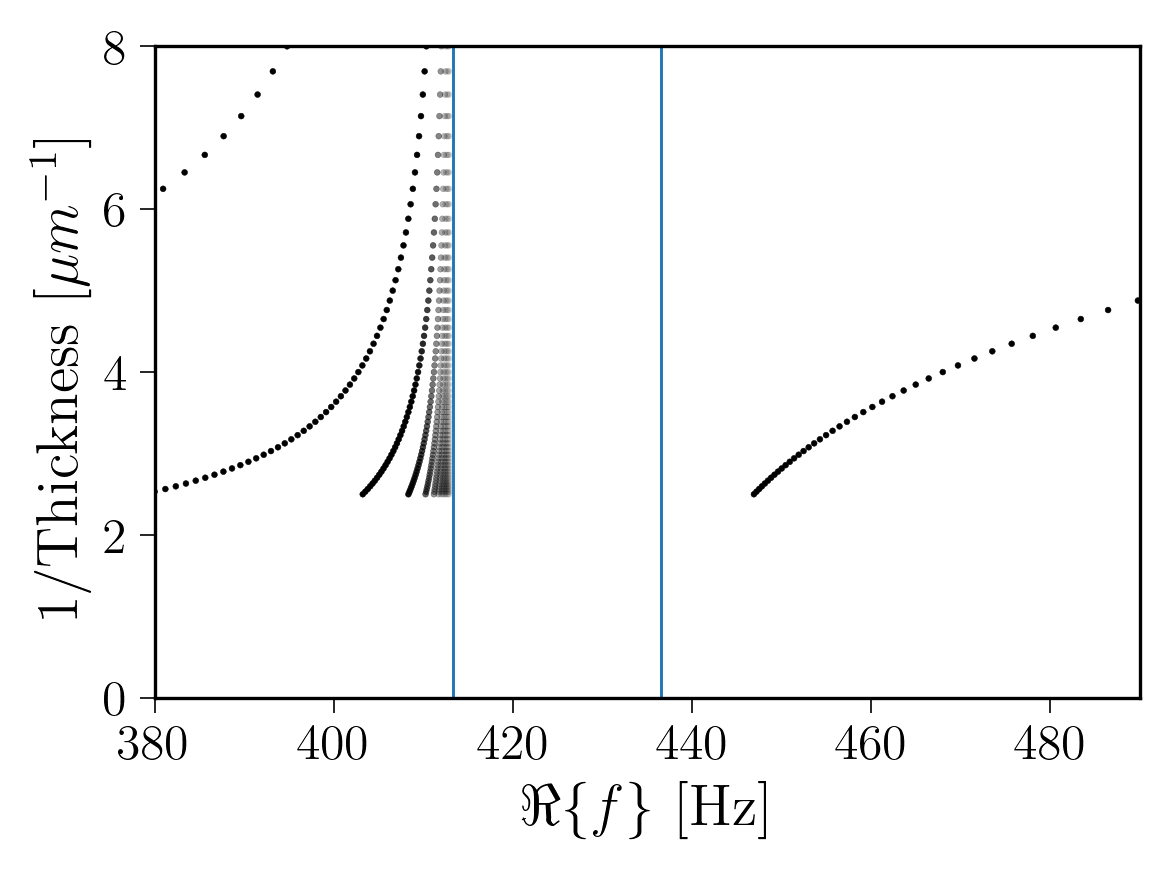

In [7]:
figsize=(90*mm,50*mm)
for t, p, r in zip(thickness, poles, residues):
    plt.scatter(np.real(p)*to_THz, [1/t]*len(p), color="k", marker=".", 
                alpha=np.clip(10*np.sqrt(np.abs(r)), 0, 1))

for line in lines:
    plt.axvline(line)

plt.ylim(0, 8)
plt.xlabel("$\Re\{f\}$ [Hz]")
plt.ylabel("1/Thickness [$\mu m^{-1}$]")
plt.xlim(freq_range)
plt.savefig("poles_inverse_thickness.pdf")

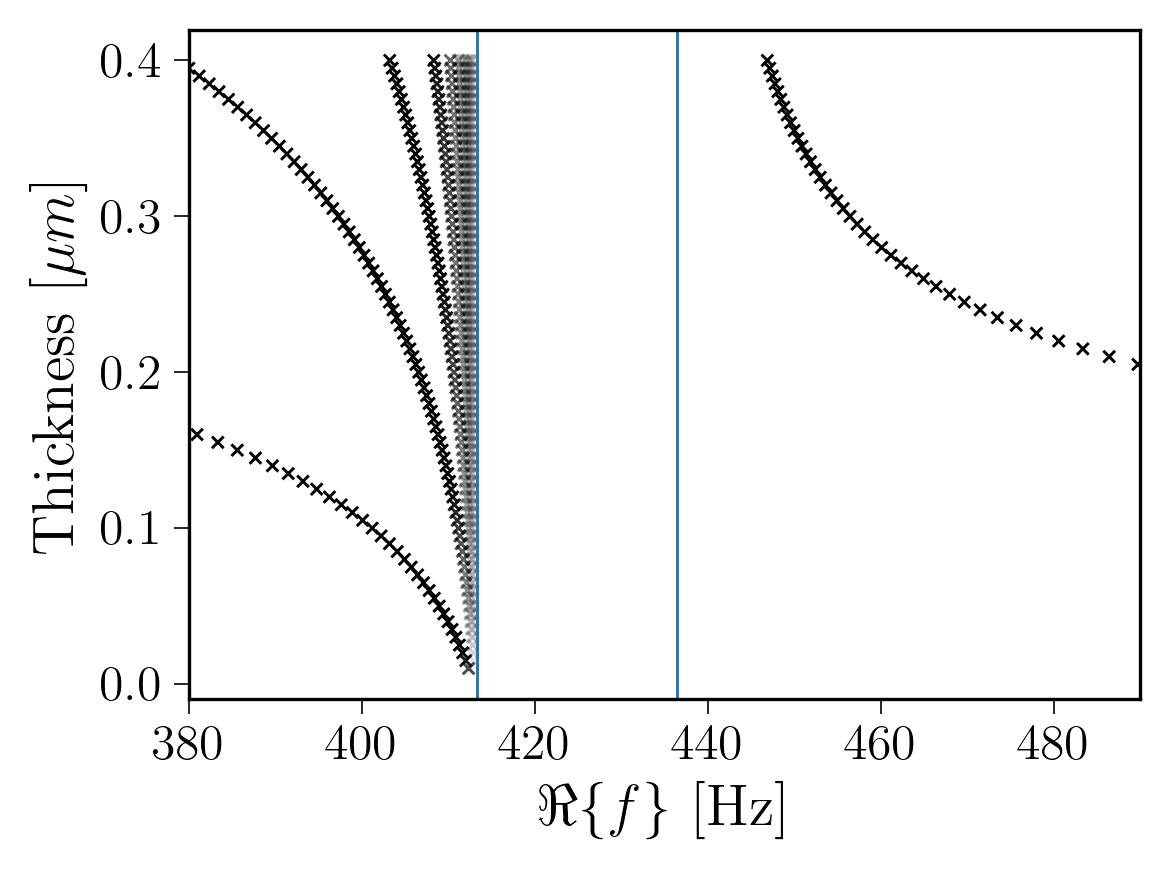

In [8]:
for t, p, r in zip(thickness, poles, residues):
    plt.scatter(np.real(p)*to_THz, [t]*len(p), color="k", marker="x", alpha=np.clip(10*np.sqrt(np.abs(r)), 0, 1))

for line in lines:
    plt.axvline(line)

plt.xlabel("$\Re\{f\}$ [Hz]")
plt.xlim(freq_range)
plt.ylabel("Thickness [$\mu m$]")
plt.savefig("poles_vs_thickness.pdf")

In [9]:
res_prev = residues[0]
pol_prev = poles[0]
mapping_prev = np.arange(len(pol_prev))

modes = []
max_mode_idx = mapping_prev[-1]
threshold = 1

for pol, res in zip(poles, residues):
    connection_matrix = np.abs(res_prev[:, None]-res[None, :]) / np.abs(res_prev[:, None]+res[None, :])
    connection_matrix_pol = np.abs(pol_prev[:, None]-pol[None, :]) / np.abs(pol_prev[:, None]+pol[None, :]) / np.abs(res_prev[:, None]+res[None, :])
    conny = 1/(connection_matrix+connection_matrix_pol+1e-20) # high values -> strong connection

    new_mapping = np.empty(len(pol), dtype=int)
    new_mapping[:] = -1
    while np.any(conny>threshold):
        conn_from, conn_to = np.unravel_index(conny.argmax(), conny.shape)
        new_mapping[conn_to] = mapping_prev[conn_from]

        conny[conn_from, :] = 0 
        conny[:, conn_to] = 0 
    
    for i, val in enumerate(new_mapping):
        if val<0:
            max_mode_idx += 1
            new_mapping[i] = max_mode_idx

    modes.append(new_mapping)
    mapping_prev = new_mapping

    res_prev = res
    pol_prev = pol

In [10]:
poles_tracked = np.empty((len(poles), max_mode_idx+1), dtype=complex)
poles_tracked[:] = np.nan
residues_tracked = poles_tracked.copy()

for i, (pol, res, mod) in enumerate(zip(poles, residues, modes)):
    for p, r, m in zip(pol, res, mod):
        poles_tracked[i, m] = p 
        residues_tracked[i, m] = r

poles_tracked_filtered = poles_tracked.copy()
poles_tracked_filtered[np.abs(residues_tracked)<1e-5] = np.nan

(-7.5, 1.0)

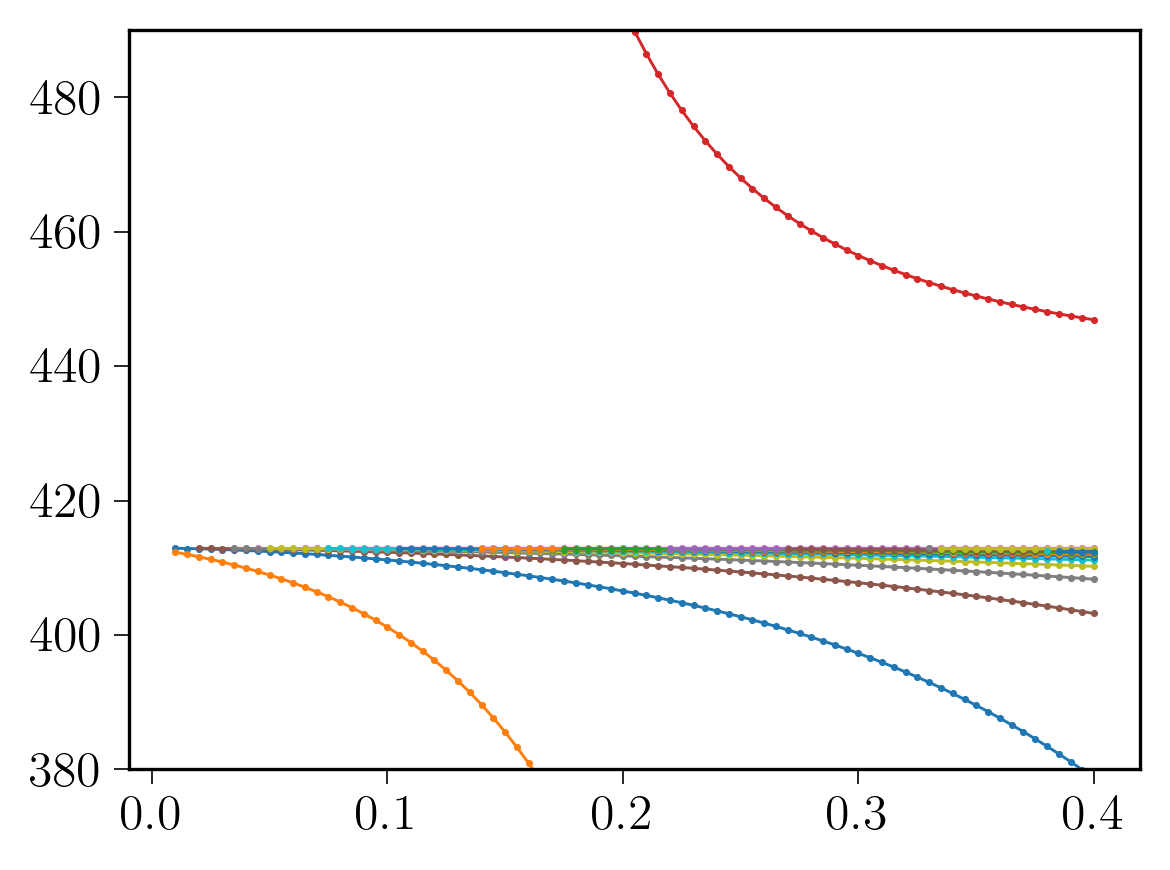

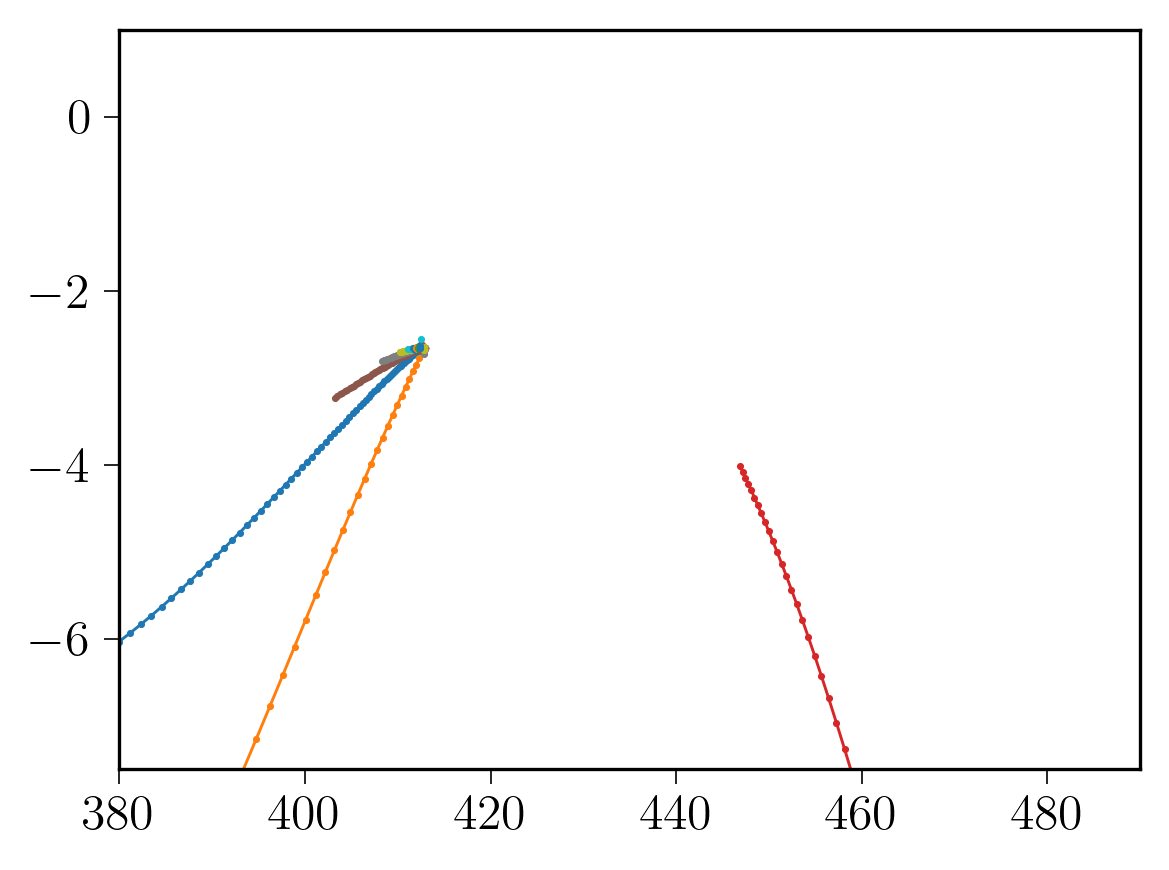

In [11]:
_ = plt.plot(thickness, poles_tracked_filtered.real*to_THz, ".-")
plt.ylim(min(w_r), max(w_r))
plt.figure()

plt.plot(poles_tracked_filtered.real*to_THz, poles_tracked_filtered.imag*to_THz, ".-")
plt.xlim(freq_range)
plt.ylim((-7.5, 1))

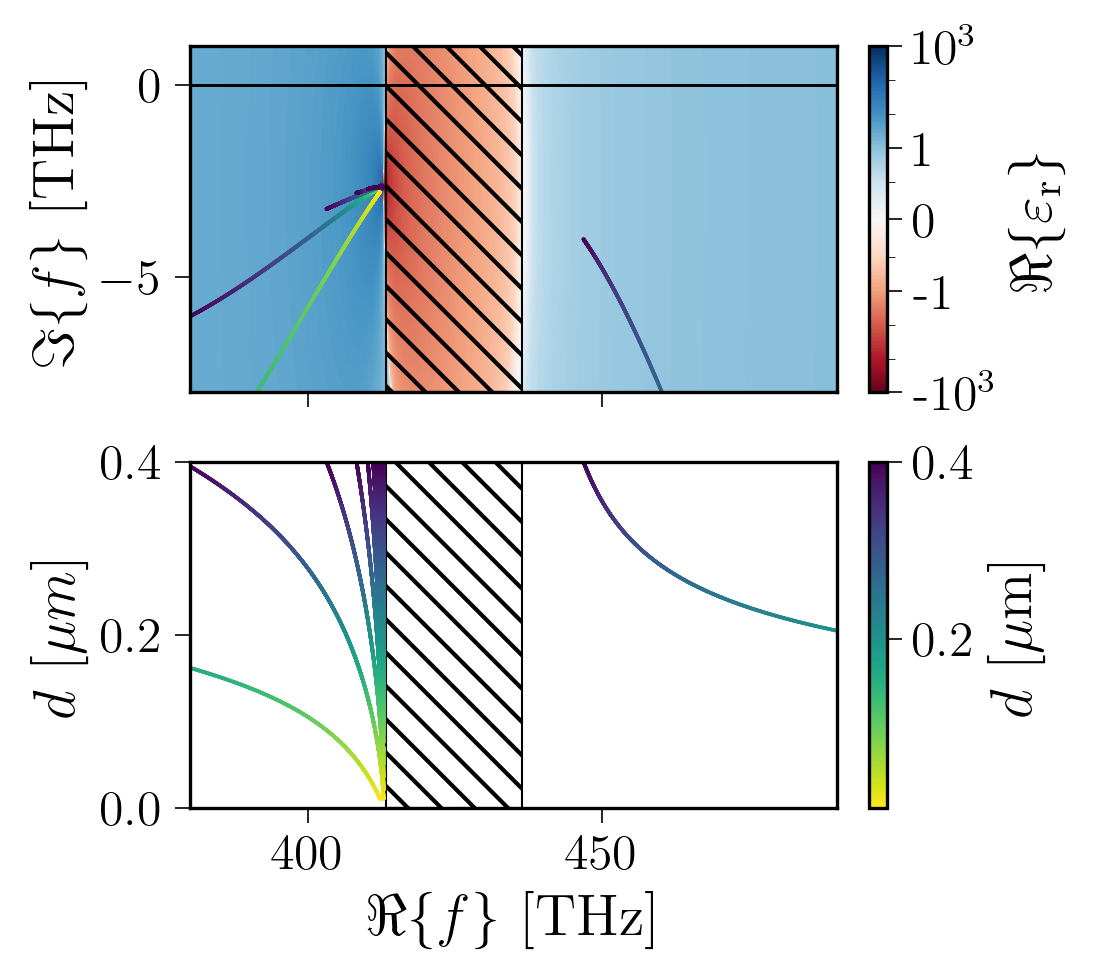

In [12]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(fig_width,80*mm), constrained_layout=True)
plt.sca(axs[0])
w_r = np.linspace(380, 490, 1200)
#w_i = np.linspace(-3.7, -2.5, 100)
w_i = np.linspace(-8, 1, 400)
#w_i = np.linspace(-600, 1, 100)
W_r, W_i = np.meshgrid(w_r, w_i)
W = W_r +1j*W_i
eps = eps_cav(W/to_THz, npoles, osc)# eps_ag(W/to_THz) #

eps_r = eps_cav(w_r/to_THz, npoles, osc)# eps_ag(w_r/to_THz) #
lines = 0.5*(w_r[:-1]+w_r[1:])[np.diff(eps_r>0)!=0]

plt.pcolormesh(W_r, W_i, np.real(eps), norm=mpl.colors.SymLogNorm(linthresh=0.1,
                                            vmin=-1000.0, vmax=1000.0, base=10),
                    cmap="RdBu", rasterized=True)
cb = plt.colorbar(label="$\Re\{\\varepsilon_\mathrm{r}\}$", ticks=[-1e3, -1, 0, 1, 1e3])
cb.set_ticklabels(["-$10^3$", -1, 0, 1, "$10^3$"])

plt.ylim(plt.ylim())
plt.xlim(plt.xlim())

cmap = mpl.cm.viridis_r
norm = mpl.colors.Normalize(vmin=min(thickness), vmax=max(thickness))
colors = cmap(norm(thickness))

interp_thick = np.linspace(min(thickness), max(thickness), 2000)
colors_interp = cmap(norm(interp_thick))
for pole in poles_tracked_filtered.T:
    real = np.interp(interp_thick, thickness, pole.real)
    imag = np.interp(interp_thick, thickness, pole.imag)
    plt.scatter(real*to_THz, imag*to_THz, c=colors_interp, edgecolor='none', s=0.8, rasterized=True)

plt.ylabel("$\Im\{f\}$ [THz]")

plt.fill_between(w_r, 0, 1, hatch="\\\\\\", where=eps_r.real<0, color="none", edgecolor="k", transform=plt.gca().get_xaxis_transform(), lw=0.5)
plt.axhline(0, color="k")

plt.sca(axs[1])
plt.fill_between(w_r, 0, 1, hatch="\\\\\\", where=eps_r.real<0, color="none", edgecolor="k", transform=plt.gca().get_xaxis_transform(), lw=0.5)
plt.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm), ax=plt.gca(), label="$d$ [$\mathrm{\mu m}$]")

for pole in poles_tracked_filtered.T:
    real = np.interp(interp_thick, thickness, pole.real)
    plt.scatter(real*to_THz, interp_thick, c=colors_interp, edgecolor='none', s=0.8, rasterized=True)
    #plt.scatter(real*to_THz, 1/interp_thick, c=colors_interp, edgecolor='none', s=0.8, rasterized=True)

# for line in lines:
#     plt.axvline(line)

plt.ylim((0, max(thickness)))
plt.ylabel("$d$ [$\mu m$]")

# plt.ylim((0, 8))
# plt.ylabel("$1/d$ [$\mu m^{-1}$]")
plt.xlim(min(w_r), max(w_r))
plt.xlabel("$\Re\{f\}$ [THz]")
plt.yticks([0, 0.2, 0.4])

plt.savefig(f"{name}_movement.pdf", dpi=600)